In [405]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from scipy.stats import boxcox
from statsmodels.tsa.stattools import grangercausalitytests

In [406]:
#Chargement des données
df = pd.read_excel(r'C:\Users\LENOVO\Downloads\Data_SP500.xlsx')
df

,Date,SP500,WTISPLC,TC
0,2014-01-01,1822.356667,94.62,1.3658
1,2014-02-01,1817.034737,100.82,1.3498
2,2014-03-01,1863.523333,100.80,1.3768
3,2014-04-01,1864.263333,102.07,1.3790
4,2014-05-01,1889.767143,102.18,1.3862
...,...,...,...,...
113,2023-06-01,4345.372857,70.25,1.0697
114,2023-07-01,4508.075500,76.07,1.0899
115,2023-08-01,4457.358696,81.39,1.0970
116,2023-09-01,4409.095000,89.43,1.0844


In [407]:
#type de données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     118 non-null    datetime64[ns]
 1   SP500    118 non-null    float64       
 2   WTISPLC  118 non-null    float64       
 3   TC       118 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 3.8 KB


In [408]:
# Définir 'Date' comme index
df = df.set_index('Date')
df

,SP500,WTISPLC,TC
Date,,,
2014-01-01,1822.356667,94.62,1.3658
2014-02-01,1817.034737,100.82,1.3498
2014-03-01,1863.523333,100.80,1.3768
2014-04-01,1864.263333,102.07,1.3790
2014-05-01,1889.767143,102.18,1.3862
...,...,...,...
2023-06-01,4345.372857,70.25,1.0697
2023-07-01,4508.075500,76.07,1.0899
2023-08-01,4457.358696,81.39,1.0970


In [409]:
df.describe()

,SP500,WTISPLC,TC
count,118.000000,118.000000,118.000000
mean,2979.437300,63.566356,1.154671
std,886.875566,20.626568,0.087625
min,1817.034737,16.550000,0.976400
25%,2119.712863,48.550000,1.094925
50%,2773.720010,59.155000,1.135200
75%,3895.068026,76.347500,1.195600
max,4674.772727,114.840000,1.386200


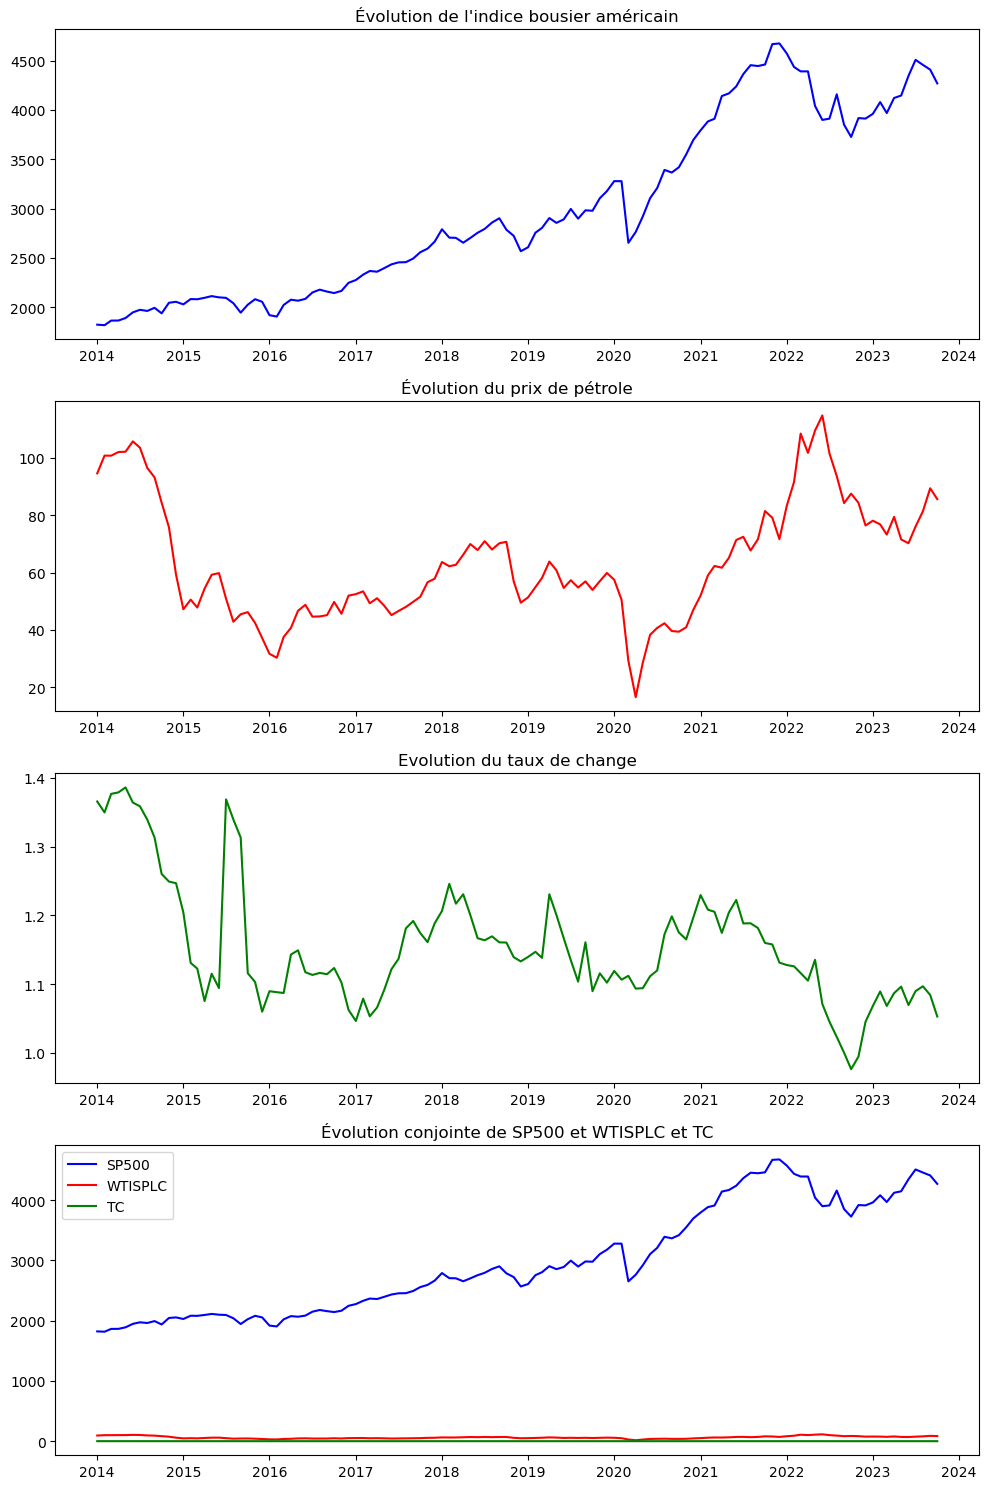

In [410]:
# Description des données
# Création d'une figure et des axes
fig, axs = plt.subplots(4, 1, figsize=(10,15))

# le premier sous-graphique pour SP500
axs[0].plot(df.index, df['SP500'], color='blue')
axs[0].set_title('Évolution de l\'indice bousier américain')

# le deuxième sous-graphique pour WTISPLC
axs[1].plot(df.index, df['WTISPLC'], color='red')
axs[1].set_title('Évolution du prix de pétrole')

#le troisième sous-graphique pour TC
axs[2].plot(df.index, df['TC'], color='green')
axs[2].set_title('Evolution du taux de change')

#le quatrième sous-graphique pour SP500, WTISPLC et TC
axs[3].plot(df.index, df['SP500'], color='blue', label='SP500')
axs[3].plot(df.index, df['WTISPLC'], color='red', label='WTISPLC')
axs[3].plot(df.index, df['TC'], color='green', label='TC')
axs[3].set_title('Évolution conjointe de SP500 et WTISPLC et TC')
axs[3].legend()

# Affichage du graphique
plt.tight_layout()
plt.show()


Results for column SP500:
ADF Statistic: -0.530267
p-value: 0.885974
Critical Values:
	1%: -3.488
	5%: -2.887
	10%: -2.580

Results for column WTISPLC:
ADF Statistic: -2.557084
p-value: 0.102195
Critical Values:
	1%: -3.488
	5%: -2.887
	10%: -2.580

Results for column TC:
ADF Statistic: -3.173230
p-value: 0.021588
Critical Values:
	1%: -3.489
	5%: -2.887
	10%: -2.580


C:\Users\LENOVO\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


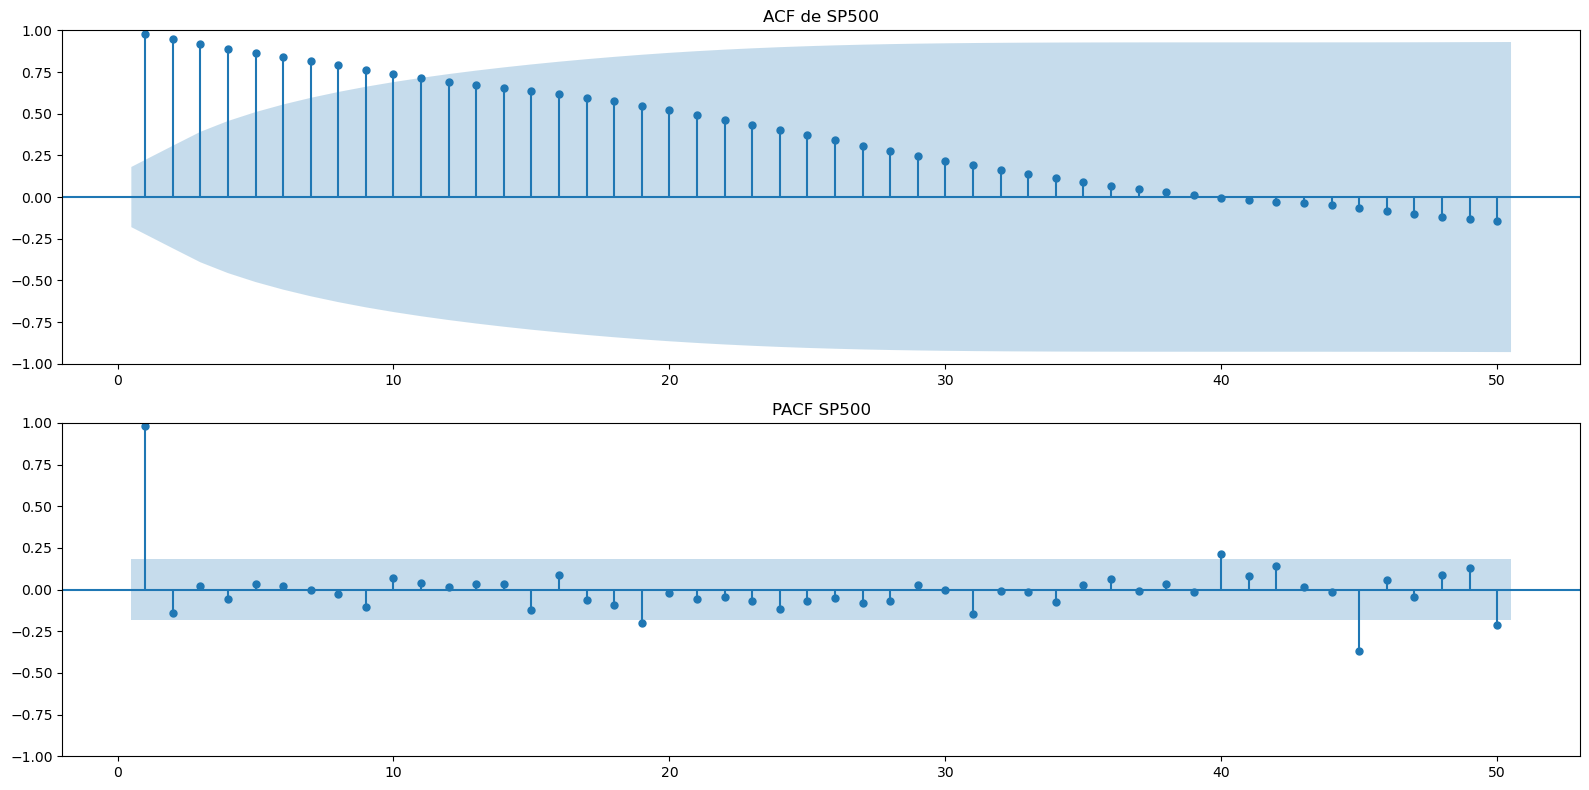

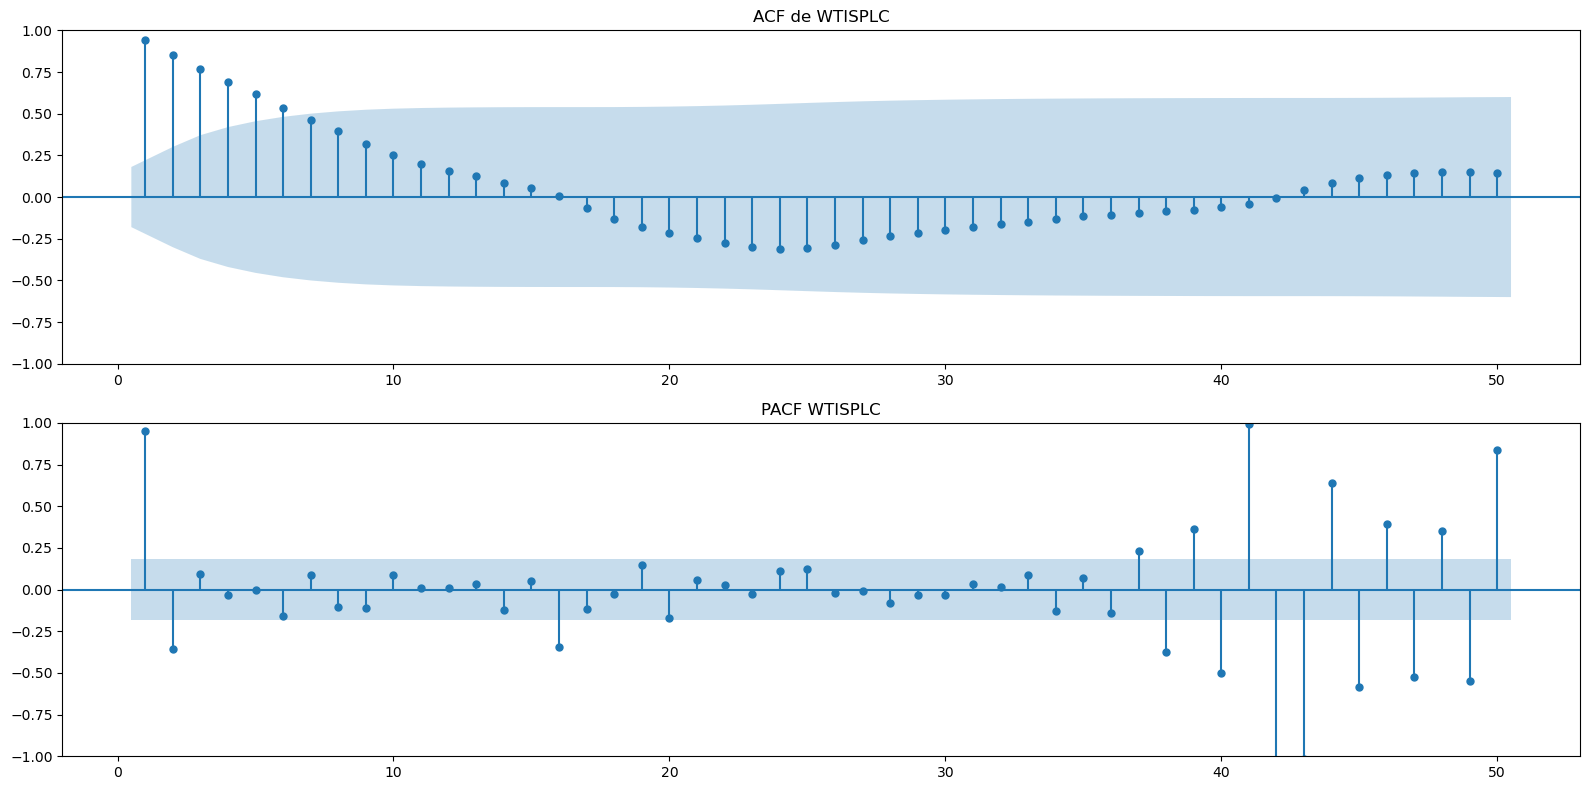

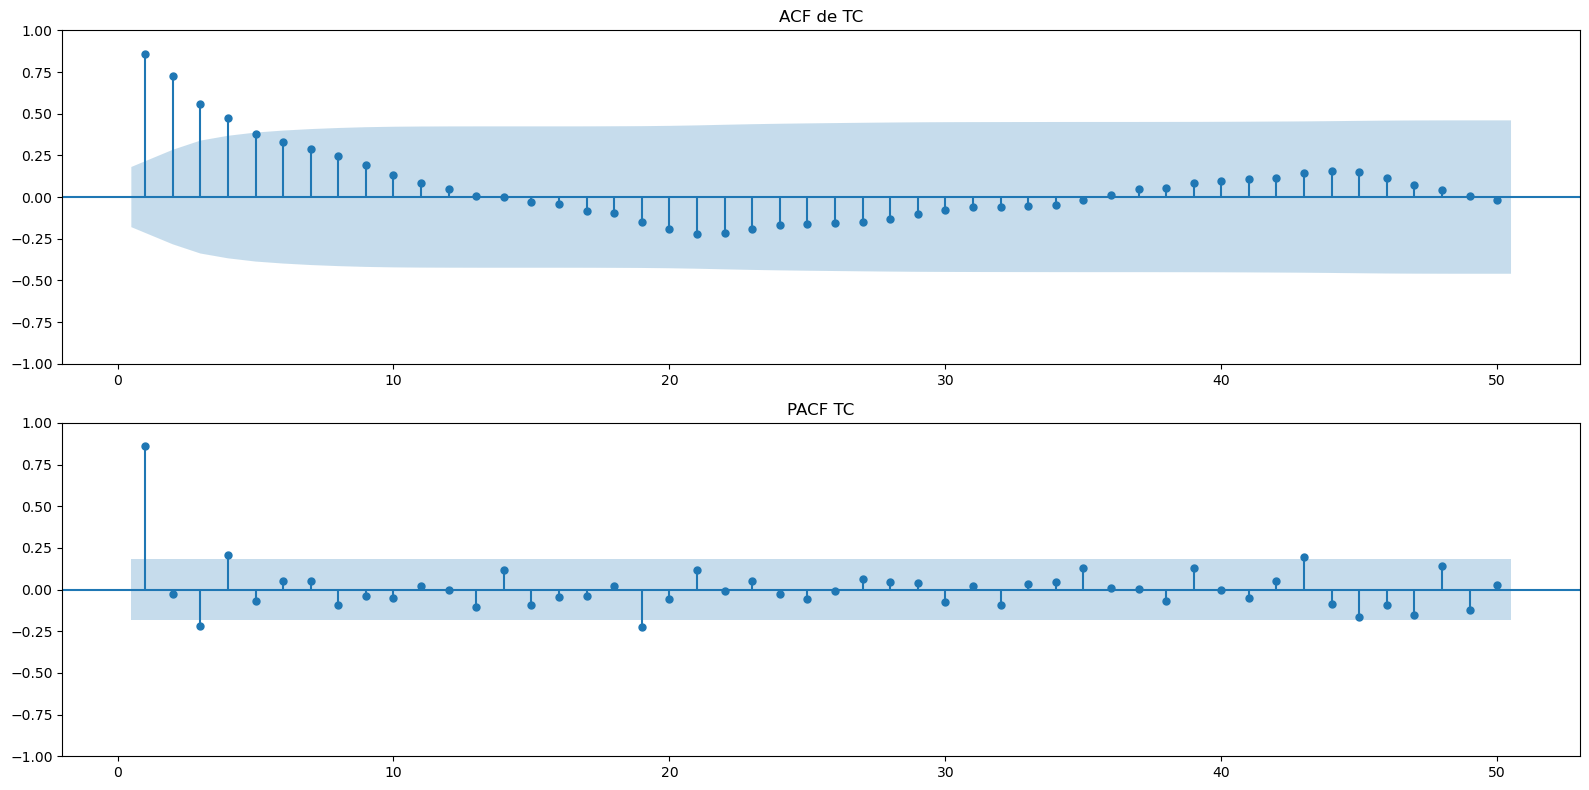

In [411]:
#Analyse de la stationnarité 
# les tests de Dickey-Fuller augmenté
for column in df.columns:
    result = adfuller(df[column])
    print(f"\nResults for column {column}:")
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

# les graphiques ACF et PACF pour chaque colonne
for column in df.columns:
    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(16,8))
    plot_acf(df[column], lags=50, zero=False, ax=ax1)
    ax1.set_title(f"ACF de {column}")
    plot_pacf(df[column], lags=50, zero=False, ax=ax2)
    ax2.set_title(f"PACF {column}")
    plt.tight_layout()
    plt.show()

In [412]:
"""
Interprétation des résultats : 
- SP500 : p-value (0.885974) est bien supérieure à 0.05, on accepte l'hypothèse nulle.
        Cela signifie que la série est non stationnaire. 
- WTISPLC: p-value (0.102195) est supérieure à 0.05.
        Nous ne pouvons pas rejeter l'hypothèse nulle. La série est non stationnaire.
- TC : p-value (0.021588) est inférieure à 0.05. On rejette H0. La série est stationnaire
Nous devons donc stationnariser les séries, 'WTISPLC'et 'SP500' avant d'effectuer nos analyses.
"""

"\nInterprétation des résultats : \n- SP500 : p-value (0.885974) est bien supérieure à 0.05, on accepte l'hypothèse nulle.\n        Cela signifie que la série est non stationnaire. \n- WTISPLC: p-value (0.102195) est supérieure à 0.05.\n        Nous ne pouvons pas rejeter l'hypothèse nulle. La série est non stationnaire.\n- TC : p-value (0.021588) est inférieure à 0.05. On rejette H0. La série est stationnaire\nNous devons donc stationnariser les séries, 'WTISPLC'et 'SP500' avant d'effectuer nos analyses.\n"

In [413]:
#Transformation des données pour rendre la série stationnaire

columns_to_diff = df.columns[:-1]
df_diff = df[columns_to_diff].diff().dropna()
df_diff.columns = [f"{col}_diff" for col in columns_to_diff]


df_2 = pd.concat([df, df_diff], axis=1)
df_2


,SP500,WTISPLC,TC,SP500_diff,WTISPLC_diff
Date,,,,,
2014-01-01,1822.356667,94.62,1.3658,NaN,NaN
2014-02-01,1817.034737,100.82,1.3498,-5.321930,6.20
2014-03-01,1863.523333,100.80,1.3768,46.488596,-0.02
2014-04-01,1864.263333,102.07,1.3790,0.740000,1.27
2014-05-01,1889.767143,102.18,1.3862,25.503810,0.11
...,...,...,...,...,...
2023-06-01,4345.372857,70.25,1.0697,199.199675,-1.33
2023-07-01,4508.075500,76.07,1.0899,162.702643,5.82
2023-08-01,4457.358696,81.39,1.0970,-50.716804,5.32


In [414]:
df_2=df_2.dropna()
df_2

,SP500,WTISPLC,TC,SP500_diff,WTISPLC_diff
Date,,,,,
2014-02-01,1817.034737,100.82,1.3498,-5.321930,6.20
2014-03-01,1863.523333,100.80,1.3768,46.488596,-0.02
2014-04-01,1864.263333,102.07,1.3790,0.740000,1.27
2014-05-01,1889.767143,102.18,1.3862,25.503810,0.11
2014-06-01,1947.087619,105.79,1.3642,57.320476,3.61
...,...,...,...,...,...
2023-06-01,4345.372857,70.25,1.0697,199.199675,-1.33
2023-07-01,4508.075500,76.07,1.0899,162.702643,5.82
2023-08-01,4457.358696,81.39,1.0970,-50.716804,5.32


In [415]:
df_3= df_2[['SP500_diff', 'WTISPLC_diff', 'TC']]
df_3

,SP500_diff,WTISPLC_diff,TC
Date,,,
2014-02-01,-5.321930,6.20,1.3498
2014-03-01,46.488596,-0.02,1.3768
2014-04-01,0.740000,1.27,1.3790
2014-05-01,25.503810,0.11,1.3862
2014-06-01,57.320476,3.61,1.3642
...,...,...,...
2023-06-01,199.199675,-1.33,1.0697
2023-07-01,162.702643,5.82,1.0899
2023-08-01,-50.716804,5.32,1.0970


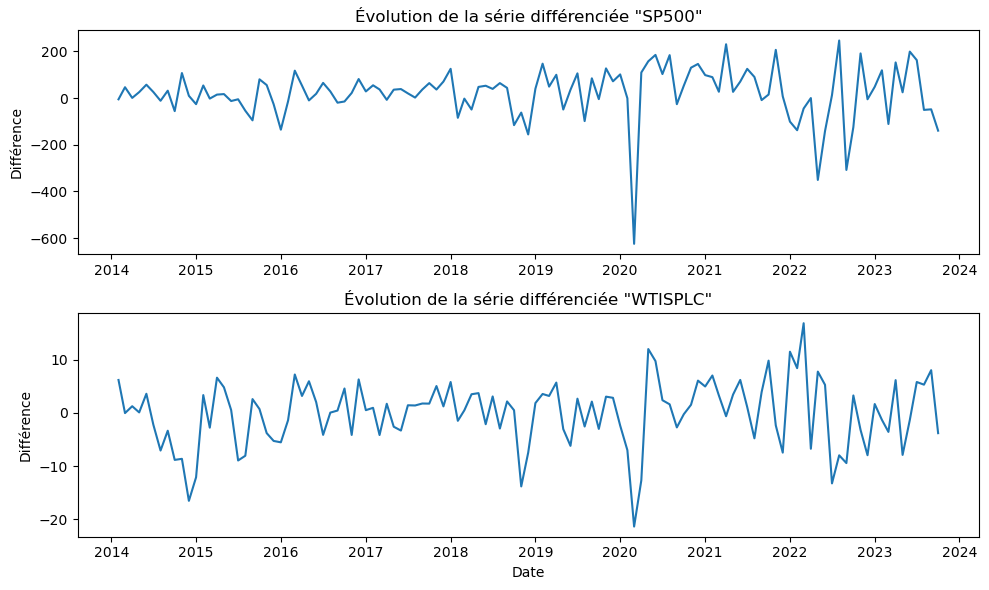

In [416]:
# les graphiques des séries différenciés
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(df_diff.index, df_diff['SP500_diff'])
plt.title('Évolution de la série différenciée "SP500"')
plt.ylabel('Différence')

plt.subplot(2, 1, 2)
plt.plot(df_diff.index, df_diff['WTISPLC_diff'])
plt.title('Évolution de la série différenciée "WTISPLC"')
plt.xlabel('Date')
plt.ylabel('Différence')

plt.tight_layout()
plt.show()


Results for column SP500_diff:
ADF Statistic: -9.753584
p-value: 0.000000
Critical Values:
	1%: -3.488
	5%: -2.887
	10%: -2.580

Results for column WTISPLC_diff:
ADF Statistic: -6.912237
p-value: 0.000000
Critical Values:
	1%: -3.489
	5%: -2.887
	10%: -2.580


C:\Users\LENOVO\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


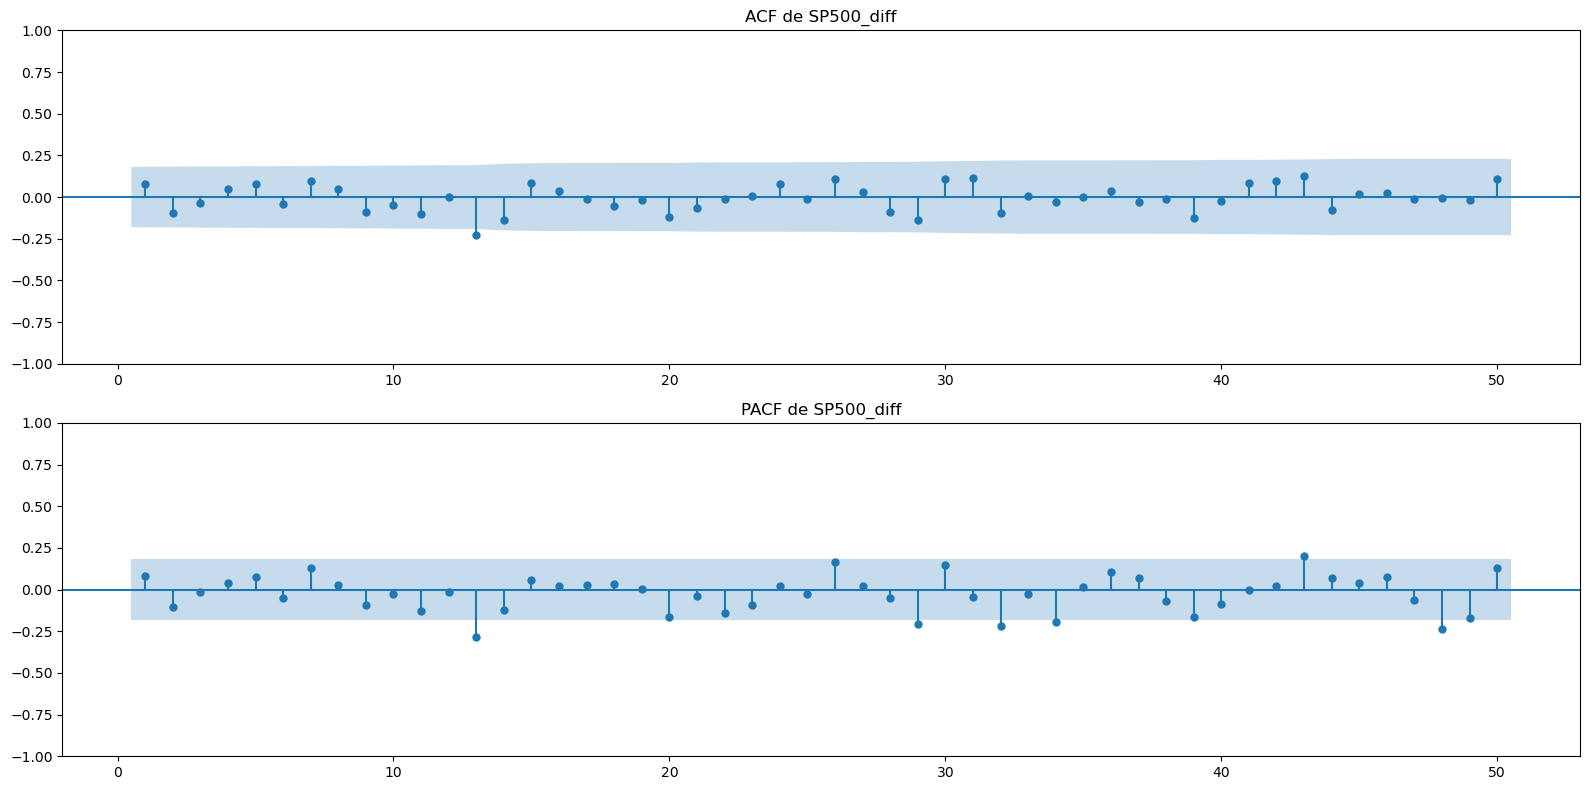

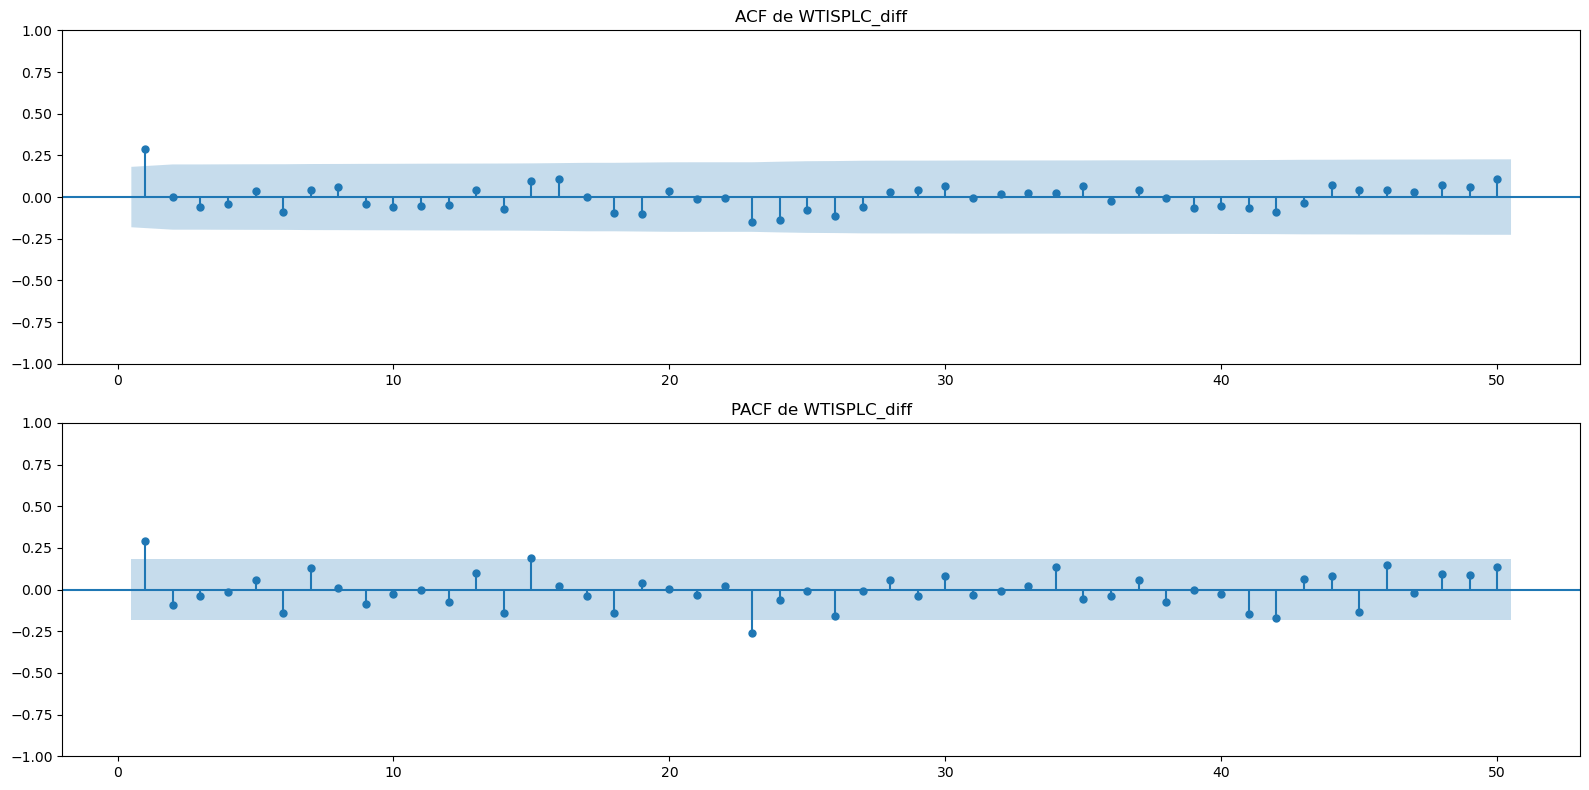

In [417]:
# les tests de Dickey-Fuller augmenté pour les séries différenciées
for column in df_diff.columns:
    result = adfuller(df_diff[column])
    print(f"\nResults for column {column}:")
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
        
# les graphiques ACF et PACF pour chaque colonne différenciée
for column in df_diff.columns:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))
    plot_acf(df_diff[column], lags=50, zero=False, ax=ax1)  # Utilisez df_diff
    ax1.set_title(f"ACF de {column}")
    plot_pacf(df_diff[column], lags=50, zero=False, ax=ax2)  # Utilisez df_diff
    ax2.set_title(f"PACF de {column}")
    plt.tight_layout()
    plt.show()


In [418]:
"""
Interprétation des résultats des séries différenciées : 
- SP500_diff : p-value (0.000000) est également bien inférieure au seuil de 0.05. On rejette l'hypothèse nulle.
La série SP500_diff est stationnaire après différenciation. 
- WTISPLC_diff : p-value  (0.000000) est encore plus faible que 0.05.
Ce qui renforce la décision de rejeter l'hypothèse nulle.
La série WTISPLC_diff est donc stationnaire après différenciation.
Les séries sont prêtes à être utilisées.
"""

"\nInterprétation des résultats des séries différenciées : \n- SP500_diff : p-value (0.000000) est également bien inférieure au seuil de 0.05. On rejette l'hypothèse nulle.\nLa série SP500_diff est stationnaire après différenciation. \n- WTISPLC_diff : p-value  (0.000000) est encore plus faible que 0.05.\nCe qui renforce la décision de rejeter l'hypothèse nulle.\nLa série WTISPLC_diff est donc stationnaire après différenciation.\nLes séries sont prêtes à être utilisées.\n"

In [419]:
#Choix du p optimal

model = VAR(df_3)
order_selection = model.select_order(maxlags=12)
order_selection.summary()

,AIC,BIC,FPE,HQIC
0,7.569,7.645,1938.,7.600
1,6.724*,7.027*,832.1*,6.847*
2,6.770,7.301,871.6,6.985
3,6.796,7.554,896.0,7.103
4,6.774,7.760,878.1,7.173
5,6.886,8.099,985.4,7.378
6,6.943,8.384,1048.,7.527
7,6.990,8.658,1106.,7.666
8,7.064,8.960,1202.,7.832
9,7.090,9.213,1249.,7.951


In [420]:
"""
Interprétation et choix du p optimal : 
1) AIC (Akaike Information Criterion) : Plus le AIC est bas, mieux c'est.
2) BIC (Bayesian Information Criterion) :Similaire au AIC, mais avec une pénalisation plus forte pour le nombre de paramètres.
3) FPE (Final Prediction Error) :Estime l'erreur de prévision hors échantillon.
4) HQIC (Hannan-Quinn Information Criterion) : Compromis entre AIC et BIC, avec une pénalisation intermédiaire.
- Les astérisques (*) indiquent les valeurs minimales de chaque critère.
- Ces valeurs sont les meilleures selon le critère correspondant.
Ce que les résultats montrent :
    Pour AIC : l'ordre optimal est 1
    Pour BIC : l'ordre optimal est 1 
    Pour FPE : l'ordre optimal est 1
    Pour HQIC : l'ordre optimal est 1 
"""

"\nInterprétation et choix du p optimal : \n1) AIC (Akaike Information Criterion) : Plus le AIC est bas, mieux c'est.\n2) BIC (Bayesian Information Criterion) :Similaire au AIC, mais avec une pénalisation plus forte pour le nombre de paramètres.\n3) FPE (Final Prediction Error) :Estime l'erreur de prévision hors échantillon.\n4) HQIC (Hannan-Quinn Information Criterion) : Compromis entre AIC et BIC, avec une pénalisation intermédiaire.\n- Les astérisques (*) indiquent les valeurs minimales de chaque critère.\n- Ces valeurs sont les meilleures selon le critère correspondant.\nCe que les résultats montrent :\n    Pour AIC : l'ordre optimal est 1\n    Pour BIC : l'ordre optimal est 1 \n    Pour FPE : l'ordre optimal est 1\n    Pour HQIC : l'ordre optimal est 1 \n"

In [421]:
# L'ordre optimal est donné par le critère d'information d'Akaike (AIC) ou le critère d'information bayésien (BIC) 
optimal_order_aic = order_selection.aic
optimal_order_bic = order_selection.bic
optimal_order_fpe = order_selection.fpe
optimal_order_hqic = order_selection.hqic

print(f"P optimal avec AIC: {optimal_order_aic}")
print(f"P optimal avec BIC: {optimal_order_bic}")
print(f"P optimal avec FPE: {optimal_order_fpe}")
print(f"P optimal avec HQIC: {optimal_order_hqic}") 

P optimal avec AIC: 1
P optimal avec BIC: 1
P optimal avec FPE: 1
P optimal avec HQIC: 1


In [422]:
#Etude de la Co-integration : Test de Johansen
lags = 1  
johansen_test = coint_johansen(df, det_order=0, k_ar_diff=lags)


print("Eigenvalues:\n", johansen_test.eig)
print("\nTrace Statistic:\n", johansen_test.lr1)
print("\nCritical Values (Trace Test):\n", johansen_test.cvt)
print("\nMax Eigen Statistic:\n", johansen_test.lr2)
print("\nCritical Values (Max Eigen Test):\n", johansen_test.cvm)


Eigenvalues:
 [0.15117527 0.08828941 0.02064115]

Trace Statistic:
 [32.15431794 13.14162112  2.41943053]

Critical Values (Trace Test):
 [[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Max Eigen Statistic:
 [19.01269683 10.72219059  2.41943053]

Critical Values (Max Eigen Test):
 [[18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [423]:
#Etude de la Causalité au sens de Granger

model = VAR(df_3)
lag_order_aic = model.select_order(maxlags=1).aic  # Critère AIC
lag_order_bic = model.select_order(maxlags=1).bic  # Critère BIC


print(f'Critère AIC pour chaque retard : \n{lag_order_aic}')
print(f'Critère BIC pour chaque retard : \n{lag_order_bic}')


optimal_lag = 3


# Test de causalité de Granger de SP500 vers WTISPLC
print("\nTest de causalité de Granger : SP500 cause-t-il WTISPLC ?")
gc_sp500_wtisplc = grangercausalitytests(df[['SP500', 'WTISPLC']], maxlag=optimal_lag, verbose=True)

# Test de causalité de Granger de WTISPLC vers SP500
print("\nTest de causalité de Granger : WTISPLC cause-t-il SP500 ?")
gc_wtisplc_sp500 = grangercausalitytests(df[['WTISPLC', 'SP500']], maxlag=optimal_lag, verbose=True)

# Test de causalité de Granger de SP500 vers TC
print("\nTest de causalité de Granger : SP500 cause-t-il TC ?")
gc_sp500_tc = grangercausalitytests(df[['SP500', 'TC']], maxlag=optimal_lag, verbose=True)

# Test de causalité de Granger de TC vers SP500
print("\nTest de causalité de Granger : TC cause-t-il SP500 ?")
gc_tc_sp500 = grangercausalitytests(df[['TC', 'SP500']], maxlag=optimal_lag, verbose=True)

# Test de causalité de Granger de WTISPLC vers TC
print("\nTest de causalité de Granger : WTISPLC cause-t-il TC ?")
gc_wtisplc_tc = grangercausalitytests(df[['WTISPLC', 'TC']], maxlag=optimal_lag, verbose=True)

# Test de causalité de Granger de TC vers WTISPLC
print("\nTest de causalité de Granger : TC cause-t-il WTISPLC ?")
gc_tc_wtisplc = grangercausalitytests(df[['TC', 'WTISPLC']], maxlag=optimal_lag, verbose=True)


Critère AIC pour chaque retard : 
1
Critère BIC pour chaque retard : 
1

Test de causalité de Granger : SP500 cause-t-il WTISPLC ?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.8752  , p=0.0514  , df_denom=114, df_num=1
ssr based chi2 test:   chi2=3.9772  , p=0.0461  , df=1
likelihood ratio test: chi2=3.9111  , p=0.0480  , df=1
parameter F test:         F=3.8752  , p=0.0514  , df_denom=114, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.7526  , p=0.0681  , df_denom=111, df_num=2
ssr based chi2 test:   chi2=5.7533  , p=0.0563  , df=2
likelihood ratio test: chi2=5.6151  , p=0.0604  , df=2
parameter F test:         F=2.7526  , p=0.0681  , df_denom=111, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.2626  , p=0.0853  , df_denom=108, df_num=3
ssr based chi2 test:   chi2=7.2278  , p=0.0650  , df=3
likelihood ratio test: chi2=7.0097  , p=0.0716  , df=3
parameter F test:         F=2.2626  

In [424]:
#Estimation du modèle 
# Création du  modèle VAR
model = VAR(df)

# Choix d'un ordre 1
results = model.fit(1)

# Sommaire des résultats
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 25, Jan, 2025
Time:                     15:45:06
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    6.88406
Nobs:                     117.000    HQIC:                   6.71577
Log likelihood:          -872.192    FPE:                    735.711
AIC:                      6.60076    Det(Omega_mle):         665.134
--------------------------------------------------------------------
Results for equation SP500
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const            -68.672211       171.840951           -0.400           0.689
L1.SP500           1.008497         0.014322           70.415           0.000
L1.WTISPLC        -1.279983         0.592000           -2.162           

C:\Users\LENOVO\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


# Validation du modèle

In [425]:
# Obtention les résidus
residuals = results.resid
residuals

,SP500,WTISPLC,TC
Date,,,
2014-02-01,-2.981011,9.249910,0.011332
2014-03-01,58.825078,3.831608,0.051330
2014-04-01,9.256475,4.681967,0.031034
2014-05-01,35.362589,3.614506,0.036291
2014-06-01,66.196837,6.978765,0.008354
...,...,...,...
2023-06-01,186.208993,-2.394278,-0.027689
2023-07-01,149.691098,4.510502,0.016260
2023-08-01,-60.204633,3.950933,0.006790


C:\Users\LENOVO\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


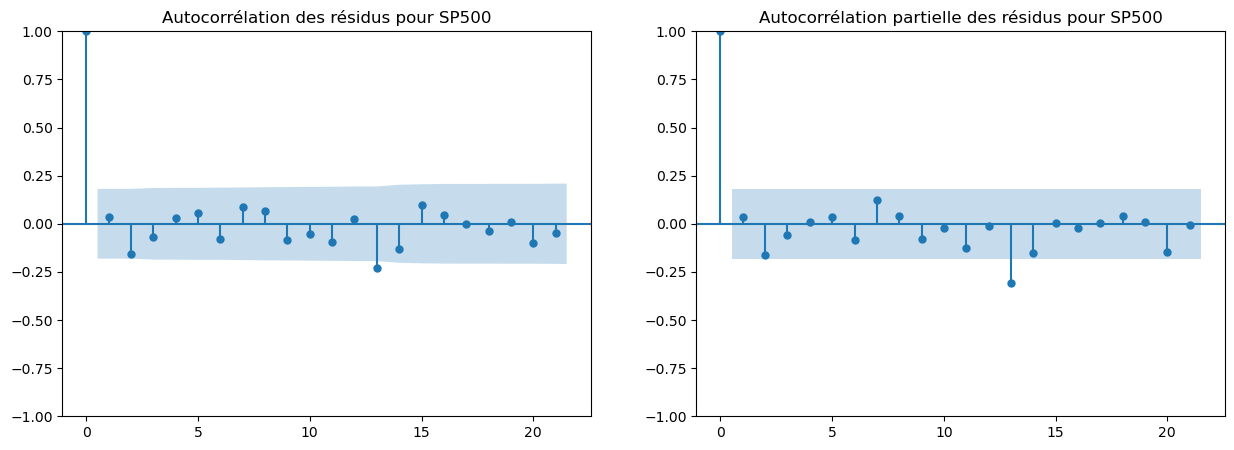

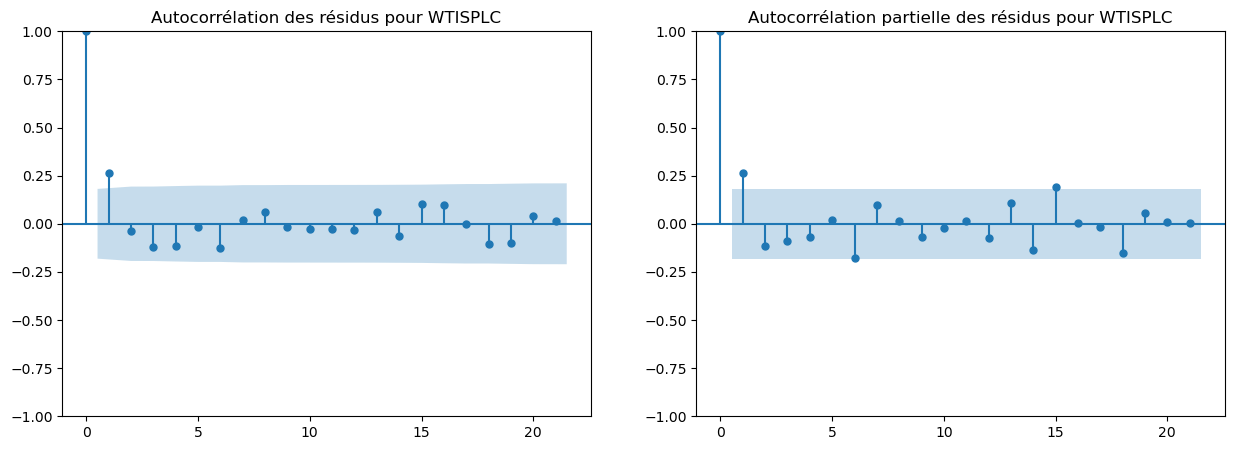

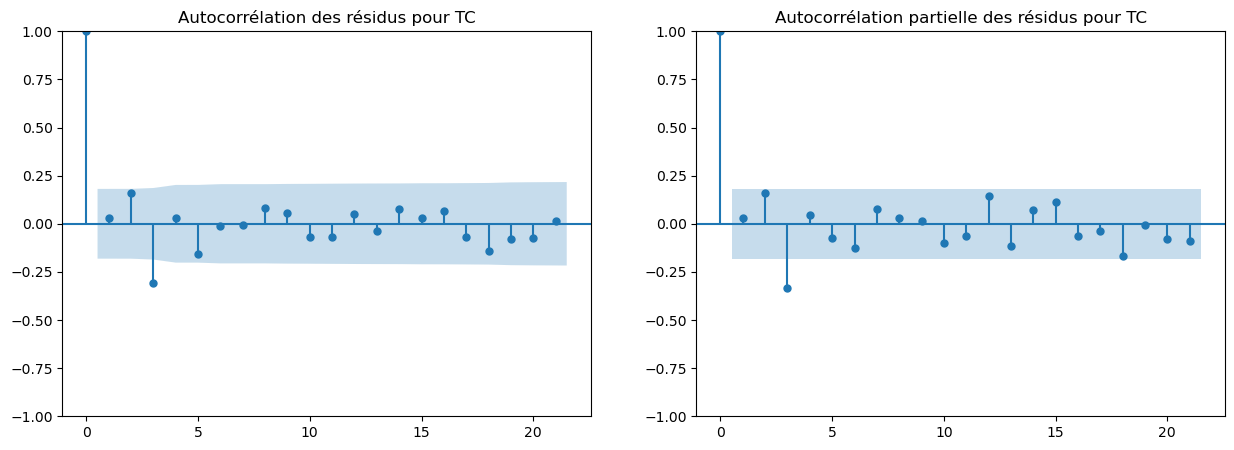

In [426]:
# l'ACF et le PACF pour chaque série de résidus
for col in residuals.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    plot_acf(residuals[col], ax=axes[0])
    axes[0].set_title(f'Autocorrélation des résidus pour {col}')
    
    plot_pacf(residuals[col], ax=axes[1])
    axes[1].set_title(f'Autocorrélation partielle des résidus pour {col}')

plt.show()

In [427]:
#Test de Jacques-Berra
import pandas as pd
import numpy as np
from statsmodels.stats.stattools import jarque_bera  
from statsmodels.tsa.api import VAR


model = VAR(df_3)
results = model.fit(1)  
residuals = results.resid
jb_results = jarque_bera(residuals)

print("Test de Jarque-Bera pour les résidus:")
print(f"Statistique de Jarque-Bera: {jb_results[0]}")
print(f"P-value: {jb_results[1]}")


Test de Jarque-Bera pour les résidus:
Statistique de Jarque-Bera: [ 404.33571467    4.94596023 1961.07881459]
P-value: [1.58348933e-88 8.43331616e-02 0.00000000e+00]


In [428]:
#Application du test Ljung-Box
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox


np.random.seed(42)
data = np.random.normal(0, 1, 100)  


lags = 10
lb_test = acorr_ljungbox(data, lags=[lags], return_df=True)


print(lb_test)


     lb_stat  lb_pvalue
10  7.468256   0.680622


In [429]:
#Test d'hétéroscédasticité de White
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import het_white
import statsmodels.api as sm

model = VAR(df_3)
results = model.fit(maxlags=4) 


residuals = results.resid

# Vérification des dimensions des résidus
print("Dimensions des résidus :", residuals.shape)
print("Colonnes des résidus :", residuals.columns)

print("\nTest de White pour chaque équation :")
for col in residuals.columns:
    print(f"\nÉquation : {col}")

    
    resid_col = residuals[col]

    
    X = pd.concat([df_3.shift(lag) for lag in range(1, results.k_ar + 1)], axis=1)
    X = X.dropna()  
    X = sm.add_constant(X, has_constant='add')

   
    resid_col = resid_col.iloc[-len(X):]  
    # Test de White
    white_test = het_white(resid_col, X)

    
    labels = ['Statistique de test', 'p-value', 'F-stat', 'p-value F-stat']
    results_dict = dict(zip(labels, white_test))

    
    for key, value in results_dict.items():
        print(f"{key}: {value:.4f}")


Dimensions des résidus : (113, 3)
Colonnes des résidus : Index(['SP500_diff', 'WTISPLC_diff', 'TC'], dtype='object')

Test de White pour chaque équation :

Équation : SP500_diff
Statistique de test: 83.1480
p-value: 0.6823
F-stat: 0.6809
p-value F-stat: 0.8940

Équation : WTISPLC_diff
Statistique de test: 98.4420
p-value: 0.2547
F-stat: 1.6529
p-value F-stat: 0.0898

Équation : TC
Statistique de test: 89.3260
p-value: 0.5002
F-stat: 0.9223
p-value F-stat: 0.6215


Racines du polynôme caractéristique du modèle VAR :
[19.01652654  3.4189254   1.16256689]
Le modèle VAR est stable.


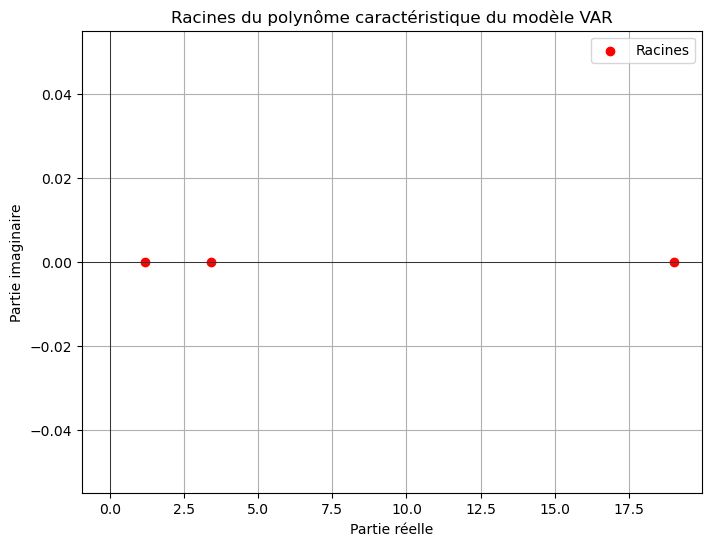

In [430]:
#Test de stabilité
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

data = df_3  

model = VAR(data)
results = model.fit(1)  

# Vérification de la stabilité du modèle VAR
roots = results.roots
print("Racines du polynôme caractéristique du modèle VAR :")
print(roots)

# Vérifier la stabilité : les racines doivent être à l'extérieur du cercle unité
unstable_roots = roots[np.abs(roots) <= 1]

if len(unstable_roots) > 0:
    print("Le modèle VAR n'est pas stable.")
else:
    print("Le modèle VAR est stable.")

# Visualisation des racines pour vérifier la stabilité
plt.figure(figsize=(8, 6))
plt.scatter(np.real(roots), np.imag(roots), color='red', label='Racines')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.title("Racines du polynôme caractéristique du modèle VAR")
plt.xlabel("Partie réelle")
plt.ylabel("Partie imaginaire")
plt.legend()
plt.grid(True)
plt.show()


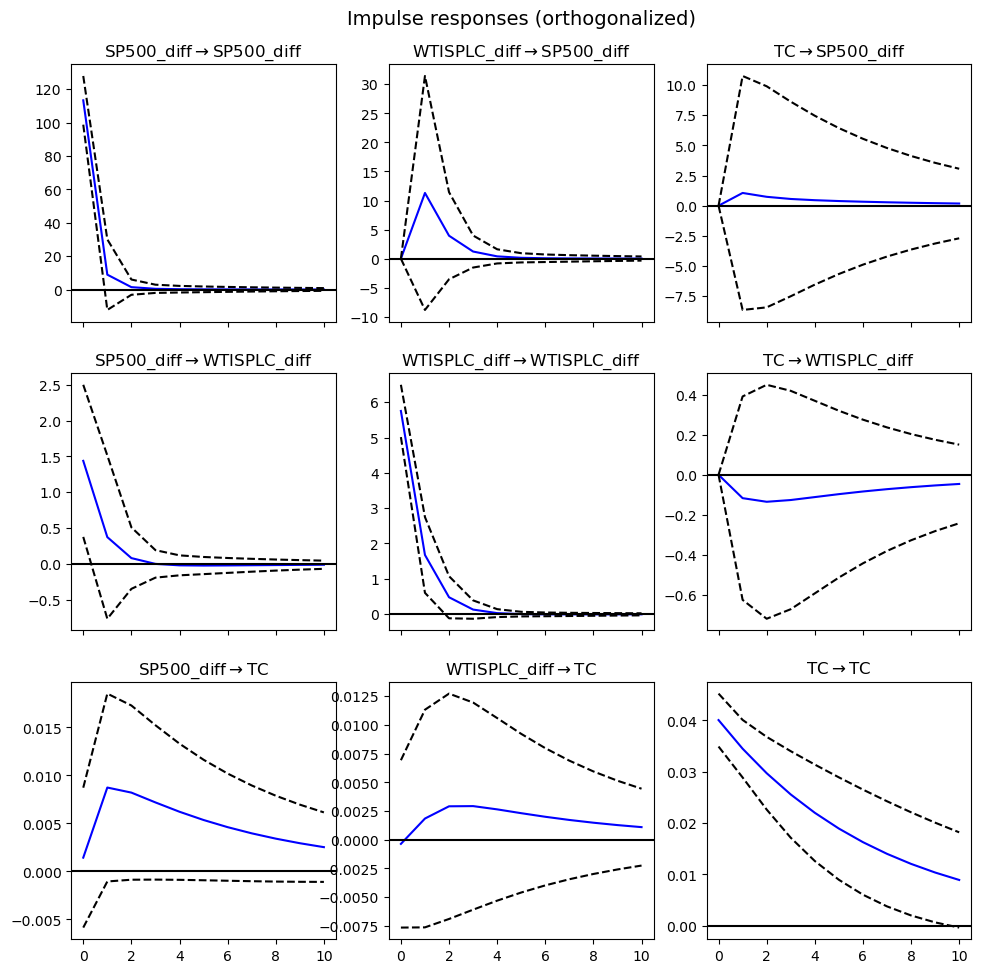

[[[ 1.13291084e+02  0.00000000e+00  0.00000000e+00]
  [ 1.43900047e+00  5.75195646e+00  0.00000000e+00]
  [ 1.42996760e-03 -3.61417605e-04  4.00489505e-02]]

 [[ 8.91891105e+00  1.13025862e+01  1.05513081e+00]
  [ 3.73140982e-01  1.67476120e+00 -1.16482845e-01]
  [ 8.73632217e-03  1.84622212e-03  3.44760161e-02]]

 [[ 1.44039274e+00  3.94602188e+00  7.35582414e-01]
  [ 7.99062866e-02  4.77821445e-01 -1.34553973e-01]
  [ 8.20896057e-03  2.91238756e-03  2.96997582e-02]]

 [[ 4.50357284e-01  1.22720832e+00  5.57139278e-01]
  [-1.15128737e-03  1.29123493e-01 -1.25803691e-01]
  [ 7.18518996e-03  2.92895153e-03  2.55617062e-02]]

 [[ 2.11091991e-01  3.96656399e-01  4.55795626e-01]
  [-2.13978731e-02  2.86048978e-02 -1.11156710e-01]
  [ 6.21260682e-03  2.64526245e-03  2.19917873e-02]]

 [[ 1.32870372e-01  1.47134721e-01  3.85134911e-01]
  [-2.43729945e-02  4.84678208e-04 -9.64745119e-02]
  [ 5.35305680e-03  2.31228285e-03  1.89178961e-02]]

 [[ 1.00195554e-01  6.97315780e-02  3.29250683e-01]


In [431]:
#Fonctions de réponses compulsionnelles
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR


model = VAR(df_3)
results = model.fit(1)  

#Calcul de la fonction compulsionnelle en 10 périodes
irf = results.irf(10)

irf.plot(orth=True) 
plt.show()

irf_data = irf.orth_irfs  
print(irf_data) 


In [432]:
#Décomposition de la variance
from statsmodels.tsa.api import VAR

# Ajustement du modèle VAR avec un ordre de 1
model = VAR(df_3)
results = model.fit(1) 

# Analyse de décomposition de variance pour 10 périodes
fevd = results.fevd(periods=10)

# Résumé du tableau d'analyse de variance
print(fevd.summary())


FEVD for SP500_diff
     SP500_diff  WTISPLC_diff        TC
0      1.000000      0.000000  0.000000
1      0.990120      0.009794  0.000085
2      0.988901      0.010973  0.000127
3      0.988763      0.011086  0.000150
4      0.988736      0.011098  0.000166
5      0.988723      0.011099  0.000178
6      0.988714      0.011100  0.000186
7      0.988708      0.011100  0.000192
8      0.988704      0.011100  0.000197
9      0.988700      0.011100  0.000200

FEVD for WTISPLC_diff
     SP500_diff  WTISPLC_diff        TC
0      0.058901      0.941099  0.000000
1      0.057984      0.941660  0.000356
2      0.057768      0.941406  0.000826
3      0.057719      0.941044  0.001237
4      0.057711      0.940731  0.001558
5      0.057711      0.940489  0.001800
6      0.057713      0.940307  0.001980
7      0.057716      0.940171  0.002113
8      0.057717      0.940071  0.002212
9      0.057718      0.939997  0.002285

FEVD for TC
     SP500_diff  WTISPLC_diff        TC
0      0.001273      0.0

Prédictions :
    SP500_diff  WTISPLC_diff        TC
0     2.469120     -0.868465  1.053093
1    15.810591     -0.070603  1.063010
2    18.353586      0.127838  1.072666
3    19.134088      0.156566  1.081210
4    19.457359      0.139791  1.088623
5    19.636947      0.113230  1.095018
6    19.762795      0.086834  1.100525
7    19.862680      0.063092  1.105263
8    19.946152      0.042366  1.109339
9    20.017237      0.024450  1.112845
10   20.078172      0.009013  1.115861
11   20.130525     -0.004273  1.118455
12   20.175539     -0.015704  1.120687
13   20.214254     -0.025536  1.122606
14   20.247553     -0.033994  1.124257
15   20.276196     -0.041270  1.125677
16   20.300833     -0.047528  1.126899
17   20.322025     -0.052910  1.127950
18   20.340254     -0.057541  1.128853
19   20.355933     -0.061523  1.129631
20   20.369421     -0.064949  1.130300
21   20.381022     -0.067896  1.130875
22   20.391001     -0.070431  1.131370
23   20.399584     -0.072611  1.131795
24   20.406

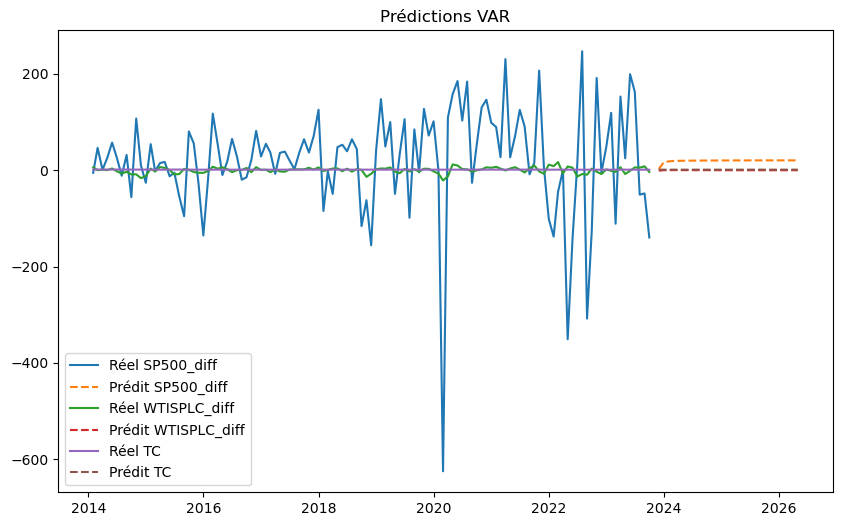

In [433]:
#Prédictions 
from statsmodels.tsa.api import VAR

model = VAR(df_3) 
results = model.fit(maxlags=1)  
last_obs = df_3.values[-results.k_ar:]  


forecast_steps = 30 #Nombre de périodes à prédire
forecast = results.forecast(last_obs, steps=forecast_steps)

#Résultat en Dataframe
import pandas as pd

forecast_df = pd.DataFrame(forecast, columns=df_3.columns)
print("Prédictions :")
print(forecast_df)
# Prédiction avec intervalles de confiance
forecast, lower, upper = results.forecast_interval(last_obs, steps=forecast_steps)

# Convertir les résultats en DataFrame
forecast_df = pd.DataFrame(forecast, columns=df_3.columns)
lower_df = pd.DataFrame(lower, columns=df_3.columns)
upper_df = pd.DataFrame(upper, columns=df_3.columns)

print("Prédictions :")
print(forecast_df)

print("Borne inférieure :")
print(lower_df)

print("Borne supérieure :")
print(upper_df)
import matplotlib.pyplot as plt

# Combiner les données réelles et prédites
forecast_range = pd.date_range(start=df_3.index[-1], periods=forecast_steps + 1, freq='M')[1:]
forecast_df.index = forecast_range

# Tracer les données réelles et prédites
plt.figure(figsize=(10, 6))
for col in df_3.columns:
    plt.plot(df_3[col], label=f"Réel {col}")
    plt.plot(forecast_df[col], '--', label=f"Prédit {col}")

plt.legend()
plt.title("Prédictions VAR")
plt.show()


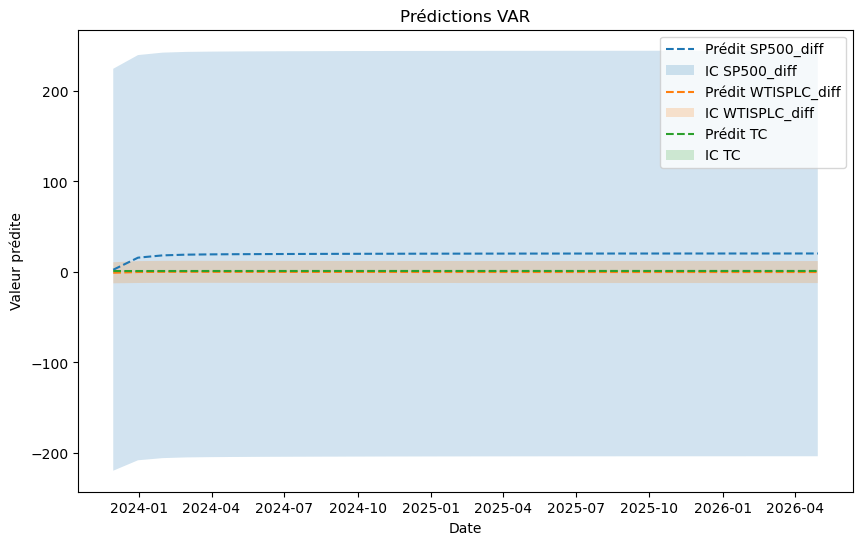

In [434]:
# Prédictions en affichant que les courbes prédites
from statsmodels.tsa.api import VAR

# Initialisation du modèle VAR
model = VAR(df_3)
results = model.fit(maxlags=1)
last_obs = df_3.values[-results.k_ar:]  

# Nombre de périodes à prédire
forecast_steps = 30
forecast = results.forecast(last_obs, steps=forecast_steps)

# Résultat des prédictions en DataFrame
import pandas as pd

forecast_df = pd.DataFrame(forecast, columns=df_3.columns)

# Convertir les résultats en DataFrame pour les intervalles de confiance
forecast, lower, upper = results.forecast_interval(last_obs, steps=forecast_steps)

forecast_df = pd.DataFrame(forecast, columns=df_3.columns)
lower_df = pd.DataFrame(lower, columns=df_3.columns)
upper_df = pd.DataFrame(upper, columns=df_3.columns)

# Définir l'index pour les prédictions
forecast_range = pd.date_range(start=df_3.index[-1], periods=forecast_steps + 1, freq='M')[1:]
forecast_df.index = forecast_range
lower_df.index = forecast_range
upper_df.index = forecast_range

# Tracer uniquement les prédictions
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for col in forecast_df.columns:
    plt.plot(forecast_df[col], '--', label=f"Prédit {col}")
    plt.fill_between(
        forecast_df.index,
        lower_df[col],
        upper_df[col],
        alpha=0.2,
        label=f"IC {col}",
    )

plt.legend()
plt.title("Prédictions VAR")
plt.xlabel("Date")
plt.ylabel("Valeur prédite")
plt.show()


In [435]:
"""
Le modèle VAR prédit une stabilisation pour toutes les séries, 
mais la grande incertitude (notamment pour SP500_diff) limite la fiabilité de ces prévisions.
Les résultats suggèrent que pour des horizons temporels plus longs, 
les prédictions peuvent devenir moins pertinentes, 
particulièrement si des chocs exogènes ou des événements imprévus surviennent.
"""

'\nLe modèle VAR prédit une stabilisation pour toutes les séries, \nmais la grande incertitude (notamment pour SP500_diff) limite la fiabilité de ces prévisions.\nLes résultats suggèrent que pour des horizons temporels plus longs, \nles prédictions peuvent devenir moins pertinentes, \nparticulièrement si des chocs exogènes ou des événements imprévus surviennent.\n'